In [1]:
import numpy as np 
import pandas as pd 

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/.DS_Store
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/val/.DS_Store
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/val/PNEUMONIA/person1947_bacteria_4876.jpeg
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/val/PNEUMONIA/person1946_bacteria_4875.jpeg
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/val/PNEUMONIA/person1952_bacteria_4883.jpeg
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/val/PNEUMONIA/person1954_bacteria_4886.jpeg
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/val/PNEUMONIA/person1951_bacteria_4882.jpeg
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/val/PNEUMONIA/person1946_bacteria_4874.jpeg
/kaggle/input/datasets/paultimothymooney

Using device: cuda

Class mapping: {'NORMAL': 0, 'PNEUMONIA': 1}
Train shape: (5216, 3)
Val shape  : (16, 3)
Test shape : (624, 3)

Dataset sizes:
Train: 5216
Val  : 16
Test : 624

Train distribution:
label_name
PNEUMONIA    3875
NORMAL       1341
Name: count, dtype: int64

Validation distribution:
label_name
NORMAL       8
PNEUMONIA    8
Name: count, dtype: int64

Test distribution:
label_name
PNEUMONIA    390
NORMAL       234
Name: count, dtype: int64


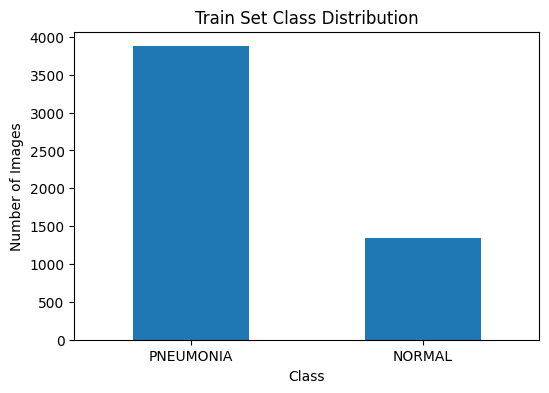

Imbalance ratio (train): 2.89

Class weights: tensor([2., 1.])

Attention-Enhanced CNN model created successfully.
Epoch [1/20] | Train Loss: 0.3517 | Train Acc: 0.9007 | Val Loss: 0.4129 | Val Acc: 0.8750 | Time: 80.2s
Epoch [2/20] | Train Loss: 0.3015 | Train Acc: 0.9287 | Val Loss: 0.5073 | Val Acc: 0.7500 | Time: 73.4s
Epoch [3/20] | Train Loss: 0.2806 | Train Acc: 0.9390 | Val Loss: 0.8727 | Val Acc: 0.6875 | Time: 70.5s
Epoch [4/20] | Train Loss: 0.2700 | Train Acc: 0.9473 | Val Loss: 0.4412 | Val Acc: 0.7500 | Time: 75.9s
Epoch [5/20] | Train Loss: 0.2612 | Train Acc: 0.9567 | Val Loss: 0.4097 | Val Acc: 0.8750 | Time: 75.1s
Epoch [6/20] | Train Loss: 0.2558 | Train Acc: 0.9634 | Val Loss: 0.3393 | Val Acc: 0.9375 | Time: 74.0s
Epoch [7/20] | Train Loss: 0.2628 | Train Acc: 0.9540 | Val Loss: 0.5572 | Val Acc: 0.8750 | Time: 73.9s
Epoch [8/20] | Train Loss: 0.2574 | Train Acc: 0.9609 | Val Loss: 0.3246 | Val Acc: 0.8750 | Time: 72.3s
Epoch [9/20] | Train Loss: 0.2568 | Train Acc

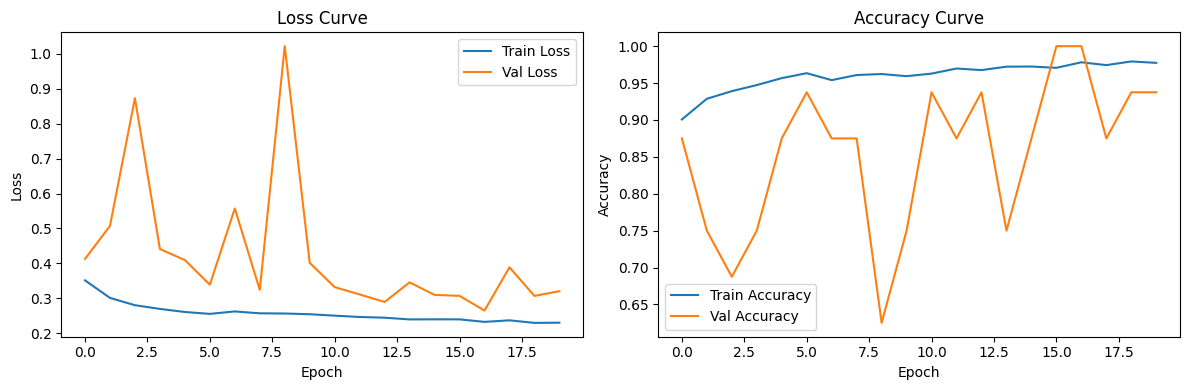


===== Test Results =====
Test Loss      : 0.4473
Test Accuracy  : 0.8910
Precision      : 0.8578
Recall         : 0.9897
F1-Score       : 0.9190
ROC-AUC        : 0.9668
Testing Time   : 8.33 seconds

Classification Report:
              precision    recall  f1-score   support

      NORMAL     0.9770    0.7265    0.8333       234
   PNEUMONIA     0.8578    0.9897    0.9190       390

    accuracy                         0.8910       624
   macro avg     0.9174    0.8581    0.8762       624
weighted avg     0.9025    0.8910    0.8869       624



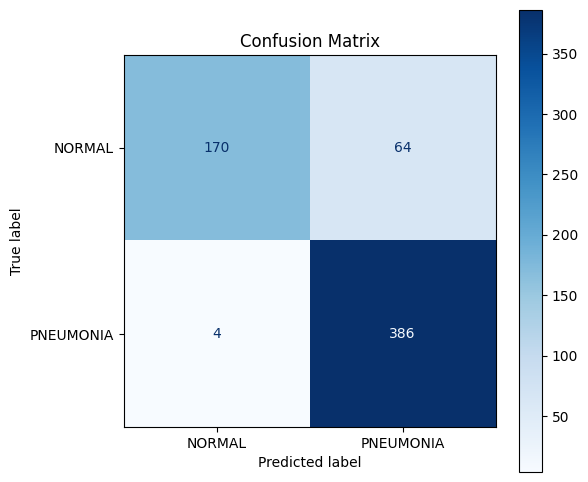

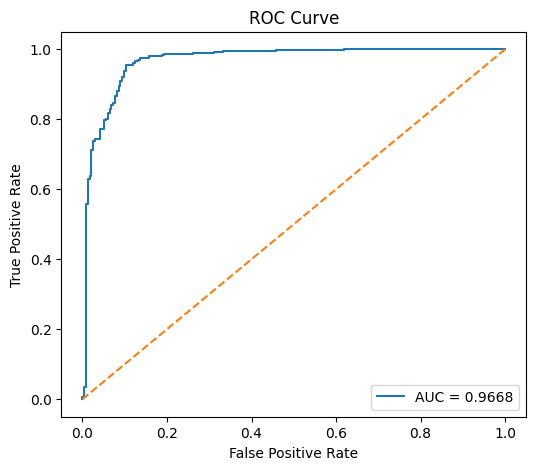


Per-class accuracy:
NORMAL: 0.7265
PNEUMONIA: 0.9897

Saved files:
/kaggle/working/attention_enhanced_cnn_best.pth
/kaggle/working/attention_enhanced_cnn_results.csv
/kaggle/working/attention_enhanced_cnn_history.csv


In [2]:
# ========================================
# ATTENTION-ENHANCED CNN FOR CHEST X-RAY PNEUMONIA
# ========================================

import os
import time
import copy
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms

warnings.filterwarnings("ignore")

# =========================
# 1. Reproducibility 
# =========================
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

def get_safe_device():
    if torch.cuda.is_available():
        try:
            _ = torch.tensor([1.0]).to("cuda")
            torch.cuda.manual_seed_all(SEED)
            return torch.device("cuda")
        except Exception:
            pass
    return torch.device("cpu")

device = get_safe_device()
print("Using device:", device)

# =========================
# 2. Dataset path
# =========================
DATASET_ROOT = "/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray"
TRAIN_DIR = os.path.join(DATASET_ROOT, "train")
VAL_DIR = os.path.join(DATASET_ROOT, "val")
TEST_DIR = os.path.join(DATASET_ROOT, "test")

IMG_EXTENSIONS = (".jpg", ".jpeg", ".png")

# =========================
# 3. Load file paths
# =========================
def collect_image_paths_and_labels(root_dir):
    data = []
    classes = sorted([d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))])
    class_to_idx = {cls_name: idx for idx, cls_name in enumerate(classes)}

    for cls_name in classes:
        cls_path = os.path.join(root_dir, cls_name)
        for file_name in os.listdir(cls_path):
            if file_name.lower().endswith(IMG_EXTENSIONS):
                file_path = os.path.join(cls_path, file_name)
                data.append([file_path, cls_name, class_to_idx[cls_name]])

    df = pd.DataFrame(data, columns=["file_path", "label_name", "label"])
    return df, class_to_idx

train_df, class_to_idx = collect_image_paths_and_labels(TRAIN_DIR)
val_df, _ = collect_image_paths_and_labels(VAL_DIR)
test_df, _ = collect_image_paths_and_labels(TEST_DIR)

idx_to_class = {v: k for k, v in class_to_idx.items()}
num_classes = len(class_to_idx)

print("\nClass mapping:", class_to_idx)
print("Train shape:", train_df.shape)
print("Val shape  :", val_df.shape)
print("Test shape :", test_df.shape)

# =========================
# 4. Reset indexes
# =========================
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("\nDataset sizes:")
print("Train:", len(train_df))
print("Val  :", len(val_df))
print("Test :", len(test_df))

# =========================
# 5. Show class distribution
# =========================
def show_distribution(df, name):
    counts = df["label_name"].value_counts()
    print(f"\n{name} distribution:")
    print(counts)
    return counts

train_counts = show_distribution(train_df, "Train")
val_counts = show_distribution(val_df, "Validation")
test_counts = show_distribution(test_df, "Test")

plt.figure(figsize=(6, 4))
train_counts.plot(kind="bar")
plt.title("Train Set Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=0)
plt.show()

imbalance_ratio = train_counts.max() / train_counts.min()
print(f"Imbalance ratio (train): {imbalance_ratio:.2f}")

# =========================
# 6. Transforms
# =========================
IMG_SIZE = 224

train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.90, 1.00)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(8),
    transforms.ColorJitter(brightness=0.10, contrast=0.10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.485, 0.485], std=[0.229, 0.229, 0.229])
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.485, 0.485], std=[0.229, 0.229, 0.229])
])

# =========================
# 7. Custom dataset
# =========================
class ChestXrayDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        image = Image.open(row["file_path"]).convert("L").convert("RGB")
        label = int(row["label"])

        if self.transform:
            image = self.transform(image)

        return image, label

train_dataset = ChestXrayDataset(train_df, transform=train_transform)
val_dataset = ChestXrayDataset(val_df, transform=eval_transform)
test_dataset = ChestXrayDataset(test_df, transform=eval_transform)

# =========================
# 8. Handle imbalance
# =========================
class_weights = torch.tensor([2.0, 1.0], dtype=torch.float, device=device)
print("\nClass weights:", class_weights.detach().cpu())

train_label_counts = train_df["label"].value_counts().sort_index().to_dict()
sample_weights = train_df["label"].map(lambda x: 1.0 / train_label_counts[x]).values
sample_weights = torch.DoubleTensor(sample_weights)

weighted_sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

# =========================
# 9. Dataloaders
# =========================
BATCH_SIZE = 32
NUM_WORKERS = 2 if device.type == "cuda" else 0
PIN_MEMORY = True if device.type == "cuda" else False

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=weighted_sampler,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

# =========================
# 10. Attention Module (SE Block)
# =========================
class SEBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super(SEBlock, self).__init__()
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y

# =========================
# 11. Attention-Enhanced CNN
# =========================
class AttentionEnhancedCNN(nn.Module):
    def __init__(self, num_classes=2):
        super(AttentionEnhancedCNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            SEBlock(32),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            SEBlock(64),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            SEBlock(128),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            SEBlock(256),
            nn.MaxPool2d(2),

            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            SEBlock(256),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.BatchNorm1d(128),
            nn.Dropout(0.4),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = AttentionEnhancedCNN(num_classes=num_classes).to(device)
print("\nAttention-Enhanced CNN model created successfully.")

# =========================
# 12. Loss, optimizer, scheduler
# =========================
criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
optimizer = optim.Adam(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    patience=2,
    factor=0.5
)

# =========================
# 13. Training and evaluation functions
# =========================
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    for images, labels in loader:
        images = images.to(device, non_blocking=(device.type == "cuda"))
        labels = labels.to(device, non_blocking=(device.type == "cuda"))

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=2.0)
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)

    return epoch_loss, epoch_acc

def evaluate(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    all_probs = []
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device, non_blocking=(device.type == "cuda"))
            labels = labels.to(device, non_blocking=(device.type == "cuda"))

            outputs = model(images)
            loss = criterion(outputs, labels)

            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(outputs, dim=1)

            running_loss += loss.item() * images.size(0)
            all_probs.extend(probs[:, 1].detach().cpu().numpy())
            all_preds.extend(preds.detach().cpu().numpy())
            all_labels.extend(labels.detach().cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)

    return epoch_loss, epoch_acc, np.array(all_labels), np.array(all_preds), np.array(all_probs)

# =========================
# 14. Training loop with early stopping
# =========================
EPOCHS = 20
PATIENCE = 5

best_val_loss = float("inf")
best_model_wts = copy.deepcopy(model.state_dict())
best_epoch = 0
early_stop_counter = 0

history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": []
}

start_train_time = time.time()

for epoch in range(EPOCHS):
    epoch_start = time.time()

    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc, _, _, _ = evaluate(model, val_loader, criterion)

    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | "
        f"Time: {time.time()-epoch_start:.1f}s"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch + 1
        best_model_wts = copy.deepcopy(model.state_dict())
        early_stop_counter = 0
        torch.save(model.state_dict(), "/kaggle/working/attention_enhanced_cnn_best.pth")
    else:
        early_stop_counter += 1
        if early_stop_counter >= PATIENCE:
            print("\nEarly stopping triggered.")
            break

total_train_time = time.time() - start_train_time
print(f"\nBest epoch: {best_epoch}")
print(f"Total training time: {total_train_time:.2f} seconds")

model.load_state_dict(best_model_wts)

# =========================
# 15. Plot history
# =========================
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history["train_acc"], label="Train Accuracy")
plt.plot(history["val_acc"], label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curve")
plt.legend()

plt.tight_layout()
plt.show()

# =========================
# 16. Final test evaluation
# =========================
start_test_time = time.time()
test_loss, test_acc, y_true, y_pred, y_prob = evaluate(model, test_loader, criterion)
test_time = time.time() - start_test_time

precision = precision_score(y_true, y_pred, average="binary")
recall = recall_score(y_true, y_pred, average="binary")
f1 = f1_score(y_true, y_pred, average="binary")
auc = roc_auc_score(y_true, y_prob)

print("\n===== Test Results =====")
print(f"Test Loss      : {test_loss:.4f}")
print(f"Test Accuracy  : {test_acc:.4f}")
print(f"Precision      : {precision:.4f}")
print(f"Recall         : {recall:.4f}")
print(f"F1-Score       : {f1:.4f}")
print(f"ROC-AUC        : {auc:.4f}")
print(f"Testing Time   : {test_time:.2f} seconds")

# =========================
# 17. Classification report
# =========================
target_names = [idx_to_class[i] for i in range(num_classes)]
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=target_names, digits=4))

# =========================
# 18. Confusion matrix
# =========================
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap="Blues", values_format="d")
plt.title("Confusion Matrix")
plt.show()

# =========================
# 19. ROC curve
# =========================
fpr, tpr, thresholds = roc_curve(y_true, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()

# =========================
# 20. Per-class accuracy
# =========================
cm = confusion_matrix(y_true, y_pred)
class_acc = cm.diagonal() / cm.sum(axis=1)

print("\nPer-class accuracy:")
for i, acc in enumerate(class_acc):
    print(f"{idx_to_class[i]}: {acc:.4f}")

# =========================
# 21. Save results
# =========================
results_df = pd.DataFrame({
    "Metric": [
        "Test Loss",
        "Test Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC",
        "Training Time (s)",
        "Testing Time (s)"
    ],
    "Value": [
        test_loss,
        test_acc,
        precision,
        recall,
        f1,
        auc,
        total_train_time,
        test_time
    ]
})

results_df.to_csv("/kaggle/working/attention_enhanced_cnn_results.csv", index=False)
pd.DataFrame(history).to_csv("/kaggle/working/attention_enhanced_cnn_history.csv", index=False)

print("\nSaved files:")
print("/kaggle/working/attention_enhanced_cnn_best.pth")
print("/kaggle/working/attention_enhanced_cnn_results.csv")
print("/kaggle/working/attention_enhanced_cnn_history.csv")